In [424]:
import pandas as pd
demand = pd.read_excel('PGCB_date_power_demand.xlsx')
print(demand.head())

             datetime  generation_mw  demand_mw  load_shedding   gas  \
0 2015-04-19 22:00:00         6323.0       6323              0     0   
1 2015-04-19 21:00:00         6667.0       6667              0     0   
2 2015-04-19 19:00:00         6897.0       6897              0  4415   
3 2015-04-19 18:30:00         6933.0       6933              0  4423   
4 2015-04-19 18:00:00         6874.0       6874              0  4319   

   liquid_fuel  coal  hydro  solar  wind  india_bheramara_hvdc  india_tripura  \
0            0     0      0    NaN   NaN                     0              0   
1            0     0      0    NaN   NaN                     0              0   
2         1836   161     41    NaN   NaN                   444              0   
3         1862   159     45    NaN   NaN                   444              0   
4         1892   155     65    NaN   NaN                   443              0   

   india_adani  nepal       remarks  
0          NaN    NaN           NaN  
1   

In [425]:
print(len(demand))

92650


In [426]:
print(demand.shape)

(92650, 15)


In [427]:
print(demand[['india_tripura', 'india_adani', 'nepal']].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   india_tripura  92650 non-null  int64  
 1   india_adani    7338 non-null   float64
 2   nepal          5351 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 2.1 MB
None


In [428]:
print(demand['india_tripura'].max()) # to check whether there is false spike or not , 1565 is not possible beacuse the capacity of  transmission line for india tripura is 160 MW approx . In reality , power transmitted through this line is way less than 160 MW

1565


In [429]:
active_tripura = demand[demand['india_tripura'] > 0].sort_index() # new dataframe in which only positive value of india tripura has been taken

# To check whether tripura line has existed for long or it started few years back


In [430]:
active_tripura.shape


(83612, 15)

# Capped the power transmitted through this line to 160 MW (maximum capacity of this line)

In [431]:
demand['india_tripura'] = demand['india_tripura'].clip(upper=160)

# Did the same thing to india_adani and nepal transmission connection


In [432]:
demand['india_adani'] = demand['india_adani'].clip(upper=1500)
demand['nepal'] = demand['nepal'].clip(upper=50)

#Missing values in the india_adani and nepal columns were replaced with zeros using fillna(0)

In [433]:
demand[['india_adani', 'nepal']] = demand[['india_adani', 'nepal']].fillna(0)

In [434]:
demand.head()


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,0.0,0.0,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,0.0,0.0,NaN
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,0.0,0.0,NaN
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,0.0,0.0,Evening_Peak
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,0.0,0.0,NaN


# 1. Missing values in solar and wind were replaced with zeros using fillna(0)
# 2. wind , solar , liquid fuel , coal , hydro and india_bheramara_hvdc transmission are capped






In [435]:
demand[['solar', 'wind']] = demand[['solar', 'wind']].fillna(0)
demand['solar'] = demand['solar'].clip(upper=500)
demand['wind'] = demand['wind'].clip(upper=100)
demand['gas'] = demand['gas'].clip(upper=8000)
demand['liquid_fuel'] = demand['liquid_fuel'].clip(upper=6500)
demand['coal'] = demand['coal'].clip(upper=5500)
demand['hydro'] = demand['hydro'].clip(upper=350)
demand['india_bheramara_hvdc'] = demand['india_bheramara_hvdc'].clip(upper=1000)

#Weighted aggregation of half hourly data(demand) into hourly data .

In [436]:
demand['datetime'] = pd.to_datetime(demand['datetime'])
demand['hour_marker'] = demand['datetime'].dt.floor('h')
demand['weight'] = demand['datetime'].dt.minute.map({0: 0.6, 30: 0.4})
demand['weight'] = demand['weight'] / demand.groupby('hour_marker')['weight'].transform('sum')

numeric_cols = demand.select_dtypes(include='number').columns.drop('weight', errors='ignore')
for col in numeric_cols:
    demand[col] = demand[col] * demand['weight']

demand = demand.groupby('hour_marker')[numeric_cols].sum().reset_index()
demand.rename(columns={'hour_marker': 'datetime'}, inplace=True)

#IQR outlier removal

In [437]:
Q1 = demand['demand_mw'].quantile(0.25)
Q3 = demand['demand_mw'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

original_count = len(demand)
demand_cleaned = demand[(demand['demand_mw'] >= lower_bound) & (demand['demand_mw'] <= upper_bound)].copy()
removed_count = original_count - len(demand_cleaned)

print(f"Original row count: {original_count}")
print(f"Rows removed as outliers: {removed_count}")
print(f"New row count: {len(demand_cleaned)}")
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

demand = demand_cleaned
display(demand['demand_mw'].describe())

Original row count: 88050
Rows removed as outliers: 87
New row count: 87963
Lower Bound: 1036.5, Upper Bound: 16336.5


,demand_mw
count,87963.000000
mean,8771.066661
std,2602.748353
min,1053.000000
25%,6773.000000
50%,8382.000000
75%,10593.000000
max,16330.000000


# Handling missing timestamps

In [438]:
full_index = pd.date_range(start=demand['datetime'].min(),
end=demand['datetime'].max(), freq='h')
demand = demand.set_index('datetime').reindex(full_index).ffill().reset_index().rename(columns={'index': 'datetime'})

#Time extraction
#Target defining
#Lag features creation

In [439]:
demand = demand.sort_values('datetime').reset_index(drop=True)

demand['hour'] = demand['datetime'].dt.hour
demand['day'] = demand['datetime'].dt.day
demand['month'] = demand['datetime'].dt.month
demand['day_of_week'] = demand['datetime'].dt.dayofweek
demand['is_weekend'] = (demand['datetime'].dt.dayofweek >= 5).astype(int)

# Shift target to the next hour (Target for time T is demand at T+1)
demand['target_next_hour_demand'] = demand['demand_mw'].shift(-1)

# Ensure all features use data from time T or earlier
demand['lag_0h'] = demand['demand_mw'].shift(0) # This is 'current' demand relative to time T , it's named as lag_0h to maintain uniformity and nothing else , it could be also named as currect demand or something like that
demand['lag_24h'] = demand['demand_mw'].shift(24)
demand['lag_168h'] = demand['demand_mw'].shift(168)

# Correcting lags to ensure they reference time T or earlier for predicting T+1
demand['demand_8760h_ago'] = demand['demand_mw'].shift(8760)
demand['rolling_mean_8760h_window'] = demand['demand_8760h_ago'].rolling(window=337, center=False).mean()

demand['rolling_mean_24h'] = demand['demand_mw'].rolling(24).mean()
demand['rolling_mean_168h'] = demand['demand_mw'].rolling(168).mean()

# Drop rows where we don't have a future target or enough lag history
demand.dropna(inplace=True)

In [440]:
print(f'New dataframe shape: {demand.shape}')
display(demand[['datetime', 'demand_mw', 'target_next_hour_demand', 'lag_0h', 'demand_8760h_ago']].head())

New dataframe shape: (80004, 27)


,datetime,demand_mw,target_next_hour_demand,lag_0h,demand_8760h_ago
9096,2016-05-02 00:00:00,4306.0,4169.0,4306.0,5669.0
9097,2016-05-02 01:00:00,4169.0,4131.0,4169.0,5395.0
9098,2016-05-02 02:00:00,4131.0,4060.0,4131.0,5244.0
9099,2016-05-02 03:00:00,4060.0,4032.0,4060.0,5132.0
9100,2016-05-02 04:00:00,4032.0,3965.0,4032.0,5049.0


In [441]:
print(f'New dataframe shape: {demand.shape}')
display(demand[['datetime', 'demand_mw', 'demand_8760h_ago', 'rolling_mean_8760h_window']].head())

New dataframe shape: (80004, 27)


,datetime,demand_mw,demand_8760h_ago,rolling_mean_8760h_window
9096,2016-05-02 00:00:00,4306.0,5669.0,5385.915529
9097,2016-05-02 01:00:00,4169.0,5395.0,5387.618793
9098,2016-05-02 02:00:00,4131.0,5244.0,5392.461523
9099,2016-05-02 03:00:00,4060.0,5132.0,5396.630663
9100,2016-05-02 04:00:00,4032.0,5049.0,5400.835410


In [442]:
print(demand.shape)
display(demand.describe())

(80004, 27)


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,...,day_of_week,is_weekend,target_next_hour_demand,lag_0h,lag_24h,lag_168h,demand_8760h_ago,rolling_mean_8760h_window,rolling_mean_24h,rolling_mean_168h
count,80004,8.000400e+04,80004.000000,80004.000000,80004.000000,80004.000000,80004.000000,80004.000000,80004.000000,80004.000000,...,80004.000000,80004.000000,80004.000000,80004.000000,80004.000000,80004.000000,80004.000000,80004.000000,80004.000000,80004.000000
mean,2020-11-23 17:30:00,9.790455e+03,9072.587773,88.214556,5215.474022,1711.223171,1065.868959,94.025618,40.124334,2.052641,...,2.998800,0.285586,9072.698180,9072.587773,9070.267957,9058.925792,8451.363565,8435.131070,9071.452620,9065.334378
min,2016-05-02 00:00:00,5.710000e+02,1053.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1053.000000,1053.000000,1053.000000,1053.000000,1053.000000,4572.444214,4170.733333,5206.305952
25%,2018-08-13 08:45:00,7.140000e+03,7139.000000,0.000000,4537.000000,732.000000,170.000000,40.000000,0.000000,0.000000,...,1.000000,0.000000,7139.000000,7139.000000,7137.000000,7130.000000,6596.950000,6722.161053,7242.200000,7274.864583
50%,2020-11-23 17:30:00,8.729000e+03,8744.000000,0.000000,5170.000000,1533.000000,520.000000,78.000000,0.000000,0.000000,...,3.000000,0.000000,8744.000000,8744.000000,8742.000000,8730.000000,8078.000000,7912.068694,8715.862500,8743.476786
75%,2023-03-07 02:15:00,1.075625e+04,10850.000000,0.000000,5890.000000,2499.000000,1481.000000,147.000000,18.600000,0.000000,...,5.000000,1.000000,10850.000000,10850.000000,10847.000000,10827.250000,10078.000000,9974.116691,10713.727083,10711.153869
max,2025-06-17 11:00:00,6.452650e+07,16330.000000,11672.000000,8000.000000,6500.000000,5500.000000,350.000000,500.000000,100.000000,...,6.000000,1.000000,16330.000000,16330.000000,16330.000000,16330.000000,16300.000000,14772.459941,15735.416667,15087.023810
std,NaN,2.281108e+05,2536.069184,307.488314,888.455794,1218.096207,1240.393774,57.947587,96.798853,7.126962,...,2.000387,0.451696,2536.053941,2536.069184,2535.461705,2529.596158,2452.385388,2135.072190,2327.759528,2242.037858


# Weather Data extraction and cleaning

In [443]:
weather = pd.read_excel('weather_data.xlsx', skiprows=4, header=None)

weather.columns = [
    'datetime', 'temp_2m', 'relative_humidity_2m', 'apparent_temp',
    'precipitation', 'dew_point_2m', 'soil_temp_0_7cm',
    'wind_direction_10m', 'cloud_cover', 'sunshine_duration'
]

weather['datetime'] = pd.to_datetime(weather['datetime'], errors='coerce')
weather = weather.dropna(subset=['datetime'])

weather = weather.sort_values('datetime').drop_duplicates('datetime')

print('Cleaned Weather Data:')
display(weather.head())

Cleaned Weather Data:


,datetime,temp_2m,relative_humidity_2m,apparent_temp,precipitation,dew_point_2m,soil_temp_0_7cm,wind_direction_10m,cloud_cover,sunshine_duration
0,2014-01-01 00:00:00,13.9,89,13.3,0.0,12.1,16.4,313,0,0.0
1,2014-01-01 01:00:00,13.6,91,13.2,0.0,12.1,16.0,317,0,0.0
2,2014-01-01 02:00:00,13.3,91,12.8,0.0,11.9,15.7,317,0,0.0
3,2014-01-01 03:00:00,13.0,92,12.5,0.0,11.8,15.4,319,0,0.0
4,2014-01-01 04:00:00,12.7,93,12.2,0.0,11.6,15.2,322,0,0.0


# Merging demand and weather data on datetime

In [444]:

merged_df = pd.merge(demand, weather, on='datetime', how='inner')

print(f"Demand rows: {len(demand)}")
print(f"Weather rows: {len(weather)}")
print(f"Merged rows: {len(merged_df)}")

display(merged_df.head())

Demand rows: 80004
Weather rows: 107304
Merged rows: 80004


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,...,rolling_mean_168h,temp_2m,relative_humidity_2m,apparent_temp,precipitation,dew_point_2m,soil_temp_0_7cm,wind_direction_10m,cloud_cover,sunshine_duration
0,2016-05-02 00:00:00,4306.0,4306.0,0.0,3597.0,321.0,86.0,36.0,0.0,0.0,...,6921.446599,25.3,90,29.3,0.0,23.5,28.2,62,75,0.0
1,2016-05-02 01:00:00,4169.0,4169.0,0.0,3488.0,284.0,87.0,37.0,0.0,0.0,...,6901.750170,24.3,89,27.2,0.0,22.4,27.8,85,80,0.0
2,2016-05-02 02:00:00,4131.0,4131.0,0.0,3446.0,287.0,88.0,38.0,0.0,0.0,...,6881.994218,24.5,90,27.8,0.0,22.7,27.7,108,46,0.0
3,2016-05-02 03:00:00,4060.0,4060.0,0.0,3405.0,257.0,86.0,39.0,0.0,0.0,...,6861.821599,24.9,91,28.8,0.0,23.3,27.6,130,55,0.0
4,2016-05-02 04:00:00,4032.0,4032.0,0.0,3375.0,259.0,86.0,40.0,0.0,0.0,...,6842.196599,25.5,91,29.7,0.0,24.0,27.7,132,56,0.0


In [445]:
weather_indicators = [col for col in weather.columns if col != 'datetime']
print(f'Total weather indicators in file: {len(weather_indicators)}')
print('Indicators available:', weather_indicators)

used_weather = [col for col in weather_indicators if col in merged_df.columns]
print(f'\nWeather indicators used in final_df: {len(used_weather)}')
print('Indicators used:', used_weather)

Total weather indicators in file: 9
Indicators available: ['temp_2m', 'relative_humidity_2m', 'apparent_temp', 'precipitation', 'dew_point_2m', 'soil_temp_0_7cm', 'wind_direction_10m', 'cloud_cover', 'sunshine_duration']

Weather indicators used in final_df: 9
Indicators used: ['temp_2m', 'relative_humidity_2m', 'apparent_temp', 'precipitation', 'dew_point_2m', 'soil_temp_0_7cm', 'wind_direction_10m', 'cloud_cover', 'sunshine_duration']


In [446]:
print(merged_df.isnull().sum())
display(merged_df.info())

datetime                     0
generation_mw                0
demand_mw                    0
load_shedding                0
gas                          0
liquid_fuel                  0
coal                         0
hydro                        0
solar                        0
wind                         0
india_bheramara_hvdc         0
india_tripura                0
india_adani                  0
nepal                        0
hour                         0
day                          0
month                        0
day_of_week                  0
is_weekend                   0
target_next_hour_demand      0
lag_0h                       0
lag_24h                      0
lag_168h                     0
demand_8760h_ago             0
rolling_mean_8760h_window    0
rolling_mean_24h             0
rolling_mean_168h            0
temp_2m                      0
relative_humidity_2m         0
apparent_temp                0
precipitation                0
dew_point_2m                 0
soil_tem

None

# Economic indicators are extracted , filtered and reshaped

In [447]:
economic = pd.read_csv('economic_full_1.csv')

bd_economic = economic[economic['Country Name'] == 'X'].copy()

indicators_map = {
    'GDP (constant 2015 US$)': 'GDP_constant',
    'Population, total': 'Population_total',
    'Industry (including construction), value added (constant 2015 US$)': 'Industry_value_added'
}

bd_filtered = bd_economic[bd_economic['Indicator Name'].isin(indicators_map.keys())]

economic_melted = bd_filtered.melt(id_vars=['Indicator Name'], var_name='year', value_name='value')
economic_melted['year'] = pd.to_numeric(economic_melted['year'], errors='coerce')
economic_melted = economic_melted.dropna(subset=['year', 'value'])

economic_pivot = economic_melted.pivot(index='year', columns='Indicator Name', values='value').reset_index()
economic_pivot.rename(columns=indicators_map, inplace=True)
economic_pivot['year'] = economic_pivot['year'].astype(int)

display(economic_pivot.tail())

Indicator Name,year,GDP_constant,Industry_value_added,Population_total
60,2020,266853000000.0,80274163392.0,166298024.0
61,2021,285369000000.0,88532058911.0,167658854.0
62,2022,305630000000.0,97257480670.0,169384897.0
63,2023,323280000000.0,105395000000.0,171466990.0
64,2024,336933000000.0,109091000000.0,173562364.0


#Integrating annual economic indicators into hourly demand dataset

In [448]:
merged_df['year'] = merged_df['datetime'].dt.year
final_df = pd.merge(merged_df, economic_pivot, on='year', how='left')
econ_cols = ['GDP_constant', 'Population_total', 'Industry_value_added']
for col in econ_cols:
    final_df[col] = pd.to_numeric(final_df[col], errors='coerce')
final_df[econ_cols] = final_df[econ_cols].interpolate(method='linear').ffill().bfill()
print(f"Final Dataset Shape with Economic Features: {final_df.shape}")
display(final_df[['datetime', 'demand_mw'] + econ_cols].head())

Final Dataset Shape with Economic Features: (80004, 40)


,datetime,demand_mw,GDP_constant,Population_total,Industry_value_added
0,2016-05-02 00:00:00,4306.0,2.090280e+11,160811932.0,5.816930e+10
1,2016-05-02 01:00:00,4169.0,2.090280e+11,160811932.0,5.816930e+10
2,2016-05-02 02:00:00,4131.0,2.090280e+11,160811932.0,5.816930e+10
3,2016-05-02 03:00:00,4060.0,2.090280e+11,160811932.0,5.816930e+10
4,2016-05-02 04:00:00,4032.0,2.090280e+11,160811932.0,5.816930e+10


In [449]:
# List all unique indicator
other_indicators = bd_economic['Indicator Name'].unique()
print(f'Total indicators found: {len(other_indicators)}')
print('\nSample of available indicators:')
for indicator in sorted([str(i) for i in other_indicators[:50]]):
    print(f'- {indicator}')

Total indicators found: 1516

Sample of available indicators:
- Age dependency ratio, old (% of working-age population)
- Battle-related deaths (number of people)
- Birth rate, crude (per 1,000 people)
- Bound rate, simple mean, manufactured products (%)
- Bound rate, simple mean, primary products (%)
- Commercial service imports (current US$)
- Completeness of birth registration, rural (%)
- Computer, communications and other services (% of commercial service exports)
- Food exports (% of merchandise exports)
- Fuel imports (% of merchandise imports)
- Intentional homicides, male (per 100,000 male)
- International tourism, expenditures (% of total imports)
- International tourism, expenditures for passenger transport items (current US$)
- International tourism, number of departures
- Life expectancy at birth, total (years)
- Manufactures exports (% of merchandise exports)
- Medium and high-tech exports (% manufactured exports)
- Merchandise exports by the reporting economy, residual (

#Merging more columns(152 columns) from the economic dataset

In [450]:
keywords = ['Urban population', 'Transport services', 'exports', 'imports']
matching_indicators = []
for indicator in other_indicators:
    if any(key.lower() in str(indicator).lower() for key in keywords):
        matching_indicators.append(indicator)
print(f"Found {len(matching_indicators)} matching indicators.")
bd_extra = bd_economic[bd_economic['Indicator Name'].isin(matching_indicators)]
economic_melted_extra = bd_extra.melt(id_vars=['Indicator Name'], var_name='year', value_name='value')
economic_melted_extra['year'] = pd.to_numeric(economic_melted_extra['year'], errors='coerce')
economic_melted_extra = economic_melted_extra.dropna(subset=['year', 'value'])
economic_pivot_extra = economic_melted_extra.pivot(index='year', columns='Indicator Name', values='value').reset_index()
economic_pivot_extra['year'] = economic_pivot_extra['year'].astype(int)
economic_pivot_extra.columns = [col.replace(' ', '_').replace('(', '').replace(')', '').replace(',', '').replace('%', 'pct') for col in economic_pivot_extra.columns]
final_df = pd.merge(final_df, economic_pivot_extra, on='year', how='left')
new_econ_cols = [c for c in economic_pivot_extra.columns if c != 'year']
final_df[new_econ_cols] = final_df[new_econ_cols].apply(pd.to_numeric, errors='coerce')
final_df[new_econ_cols] = final_df[new_econ_cols].interpolate(method='linear').ffill().bfill()
print(f"New dataset shape: {final_df.shape}")
display(final_df.head())

Found 112 matching indicators.
New dataset shape: (80004, 152)


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,...,Transport_services_pct_of_service_exports_BoP,Transport_services_pct_of_service_imports_BoP,Travel_services_pct_of_commercial_service_exports,Travel_services_pct_of_commercial_service_imports,Travel_services_pct_of_service_exports_BoP,Travel_services_pct_of_service_imports_BoP,Urban_population,Urban_population_pct_of_total_population,Urban_population_growth_annual_pct,Urban_population_living_in_areas_where_elevation_is_below_5_meters_pct_of_total_population
0,2016-05-02 00:00:00,4306.0,4306.0,0.0,3597.0,321.0,86.0,36.0,0.0,0.0,...,11.805471,69.278559,10.636501,6.364097,6.03108,6.199382,48043194.0,29.875392,2.023075,NaN
1,2016-05-02 01:00:00,4169.0,4169.0,0.0,3488.0,284.0,87.0,37.0,0.0,0.0,...,11.805471,69.278559,10.636501,6.364097,6.03108,6.199382,48043194.0,29.875392,2.023075,NaN
2,2016-05-02 02:00:00,4131.0,4131.0,0.0,3446.0,287.0,88.0,38.0,0.0,0.0,...,11.805471,69.278559,10.636501,6.364097,6.03108,6.199382,48043194.0,29.875392,2.023075,NaN
3,2016-05-02 03:00:00,4060.0,4060.0,0.0,3405.0,257.0,86.0,39.0,0.0,0.0,...,11.805471,69.278559,10.636501,6.364097,6.03108,6.199382,48043194.0,29.875392,2.023075,NaN
4,2016-05-02 04:00:00,4032.0,4032.0,0.0,3375.0,259.0,86.0,40.0,0.0,0.0,...,11.805471,69.278559,10.636501,6.364097,6.03108,6.199382,48043194.0,29.875392,2.023075,NaN


# Creating dataset for training (final_df_train)

In [451]:
final_df_train = final_df[final_df['datetime'].dt.year <= 2023].copy()

print(f"Original dataset range: {final_df['datetime'].min()} to {final_df['datetime'].max()}")
print(f"Training dataset range: {final_df_train['datetime'].min()} to {final_df_train['datetime'].max()}")
print(f"Rows in training set: {len(final_df_train)}")

display(final_df_train.tail())

Original dataset range: 2016-05-02 00:00:00 to 2025-06-17 11:00:00
Training dataset range: 2016-05-02 00:00:00 to 2023-12-31 23:00:00
Rows in training set: 67200


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,...,Transport_services_pct_of_service_exports_BoP,Transport_services_pct_of_service_imports_BoP,Travel_services_pct_of_commercial_service_exports,Travel_services_pct_of_commercial_service_imports,Travel_services_pct_of_service_exports_BoP,Travel_services_pct_of_service_imports_BoP,Urban_population,Urban_population_pct_of_total_population,Urban_population_growth_annual_pct,Urban_population_living_in_areas_where_elevation_is_below_5_meters_pct_of_total_population
67195,2023-12-31 19:00:00,9894.0,9894.0,0.0,4127.0,1197.0,3467.0,86.0,0.0,0.0,...,12.11628,61.105295,10.084155,15.683371,7.113293,15.270174,55140091.0,32.157846,2.738584,NaN
67196,2023-12-31 20:00:00,9669.0,9669.0,0.0,4050.0,1048.0,3471.0,86.0,0.0,0.0,...,12.11628,61.105295,10.084155,15.683371,7.113293,15.270174,55140091.0,32.157846,2.738584,NaN
67197,2023-12-31 21:00:00,9250.0,9250.0,0.0,3954.0,845.0,3355.0,86.0,0.0,0.0,...,12.11628,61.105295,10.084155,15.683371,7.113293,15.270174,55140091.0,32.157846,2.738584,NaN
67198,2023-12-31 22:00:00,8690.0,8690.0,0.0,3879.0,555.0,3162.0,86.0,0.0,0.0,...,12.11628,61.105295,10.084155,15.683371,7.113293,15.270174,55140091.0,32.157846,2.738584,NaN
67199,2023-12-31 23:00:00,8039.0,8039.0,0.0,3857.0,75.0,3205.0,86.0,0.0,0.0,...,12.11628,61.105295,10.084155,15.683371,7.113293,15.270174,55140091.0,32.157846,2.738584,NaN


## **MODEL TRAINING**

In [452]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_percentage_error , mean_absolute_error, r2_score
import numpy as np
# We exclude 'datetime' and columns that are directly related to generation or are target-leakage
features = final_df_train.drop(columns=['datetime','target_next_hour_demand' , 'demand_mw', 'generation_mw', 'load_shedding', 'remarks', 'year'], errors='ignore')
target = final_df_train['target_next_hour_demand']

# Split into training and validation sets (80/20)
X_train, X_val, y_train, y_val = train_test_split(features, target, test_size=0.2, random_state=42, shuffle=False)

# Initialize and train XGBoost Regressor
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=50
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

# Make predictions
preds = model.predict(X_val)

# Evaluation Metrics
rmse = np.sqrt(mean_squared_error(y_val, preds))
mae = mean_absolute_error(y_val, preds)
r2 = r2_score(y_val, preds)

print(f"\nEvaluation Metrics:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")

[0]	validation_0-rmse:3335.84211
[100]	validation_0-rmse:623.69529
[200]	validation_0-rmse:615.74238
[226]	validation_0-rmse:615.16773

Evaluation Metrics:
RMSE: 611.70
MAE: 302.53
R2 Score: 0.9258


In [453]:
# just for checking that training dataset and validation dataset on which the model is trained is correct or not
print(f"Full training data: {final_df_train['datetime'].min()} to {final_df_train['datetime'].max()}")
print(f"X_train: {X_train.index[0]} to {X_train.index[-1]}")
print(f"X_val: {X_val.index[0]} to {X_val.index[-1]}")

Full training data: 2016-05-02 00:00:00 to 2023-12-31 23:00:00
X_train: 0 to 53759
X_val: 53760 to 67199


#MAPE Calculation on the validation set

In [454]:
mape = mean_absolute_percentage_error(y_val, preds)
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2%}")

Mean Absolute Percentage Error (MAPE): 3.81%


#Graph representing predictions v/s actual demand for the validations set (last 20% of the final_df_train) and feature importance

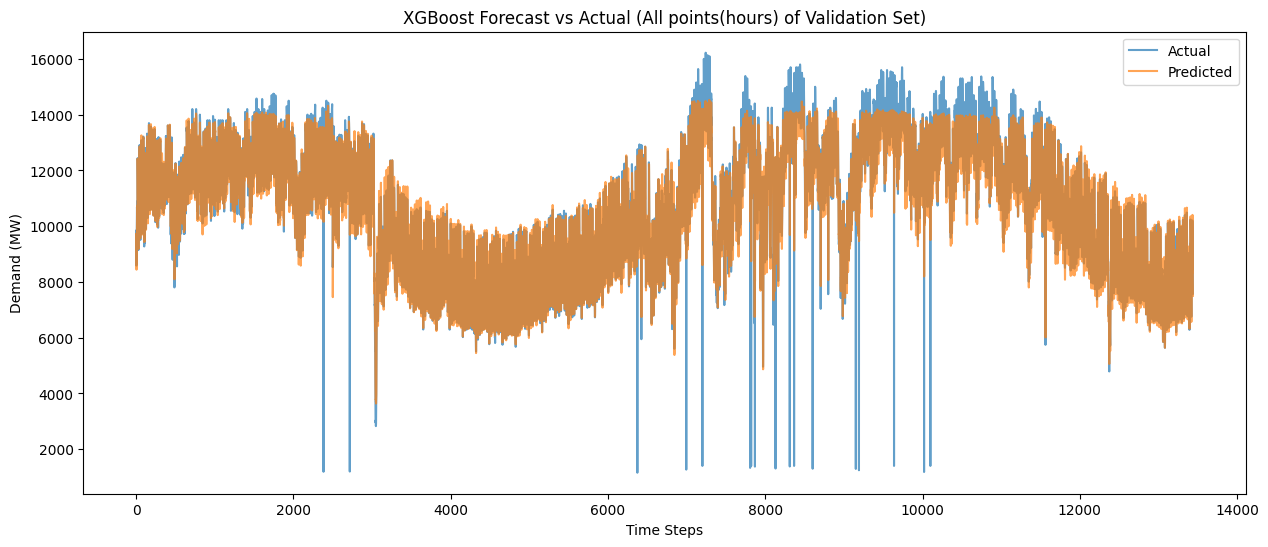

<Figure size 1000x800 with 0 Axes>

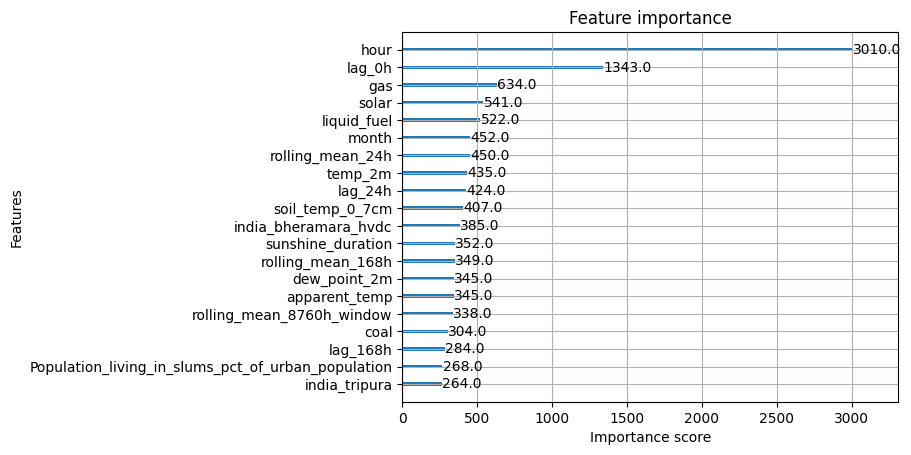

In [455]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 6))
plt.plot(y_val.values[:13474], label='Actual', alpha=0.7)
plt.plot(preds[:13474], label='Predicted', alpha=0.7)
plt.title('XGBoost Forecast vs Actual (All points(hours) of Validation Set)')
plt.xlabel('Time Steps')
plt.ylabel('Demand (MW)')
plt.legend()
plt.show()

# Feature Importance
plt.figure(figsize=(10, 8))
xgb.plot_importance(model, max_num_features=20)
plt.show()

#MAPE on the demand prediction for year 2024  

In [456]:
df_2024 = final_df[final_df['datetime'].dt.year == 2024].copy()

X_2024 = df_2024.drop(columns=['datetime','target_next_hour_demand', 'demand_mw', 'generation_mw', 'load_shedding', 'remarks', 'year'], errors='ignore')
y_2024 = df_2024['target_next_hour_demand']

preds_2024 = model.predict(X_2024)

mape_2024 = mean_absolute_percentage_error(y_2024, preds_2024)

print(f'Evaluation for Year 2024:')
print(f'Rows in 2024: {len(df_2024)}')
print(f'Mean Absolute Percentage Error (MAPE): {mape_2024:.2%}')

Evaluation for Year 2024:
Rows in 2024: 8784
Mean Absolute Percentage Error (MAPE): 4.87%


#Graph representing predicted values and actual values for the first 500 hours(or points) for the year 2024

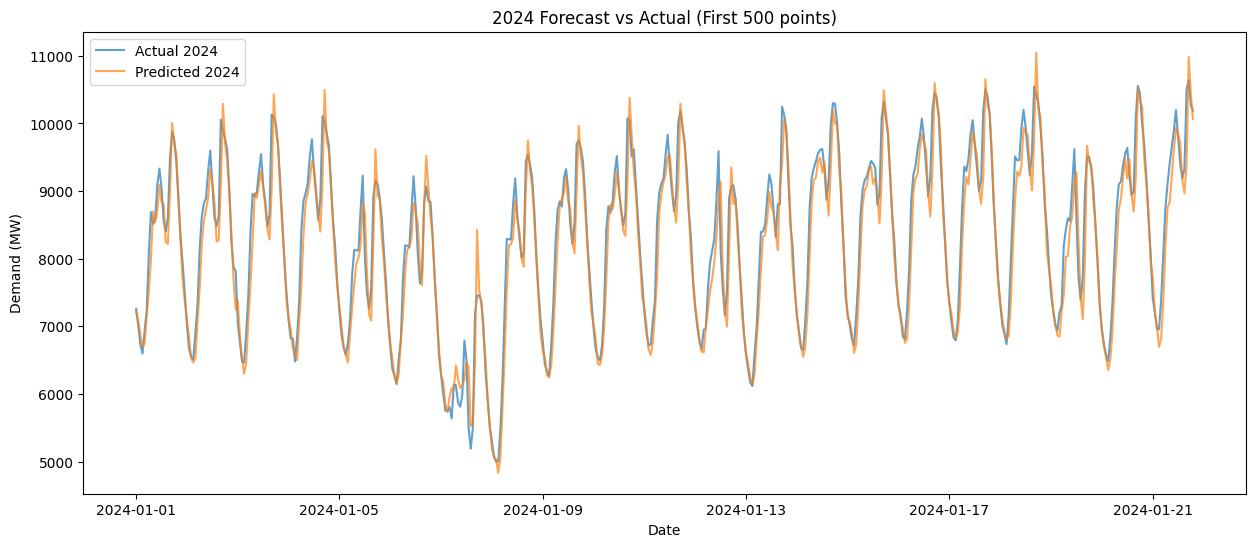

In [457]:
plt.figure(figsize=(15, 6))
plt.plot(df_2024['datetime'].values[:500], y_2024.values[:500], label='Actual 2024', alpha=0.7)
plt.plot(df_2024['datetime'].values[:500], preds_2024[:500], label='Predicted 2024', alpha=0.7)
plt.title('2024 Forecast vs Actual (First 500 points)')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.legend()
plt.show()

# Visualizing the actual versus predicted demand for the entire year 2024

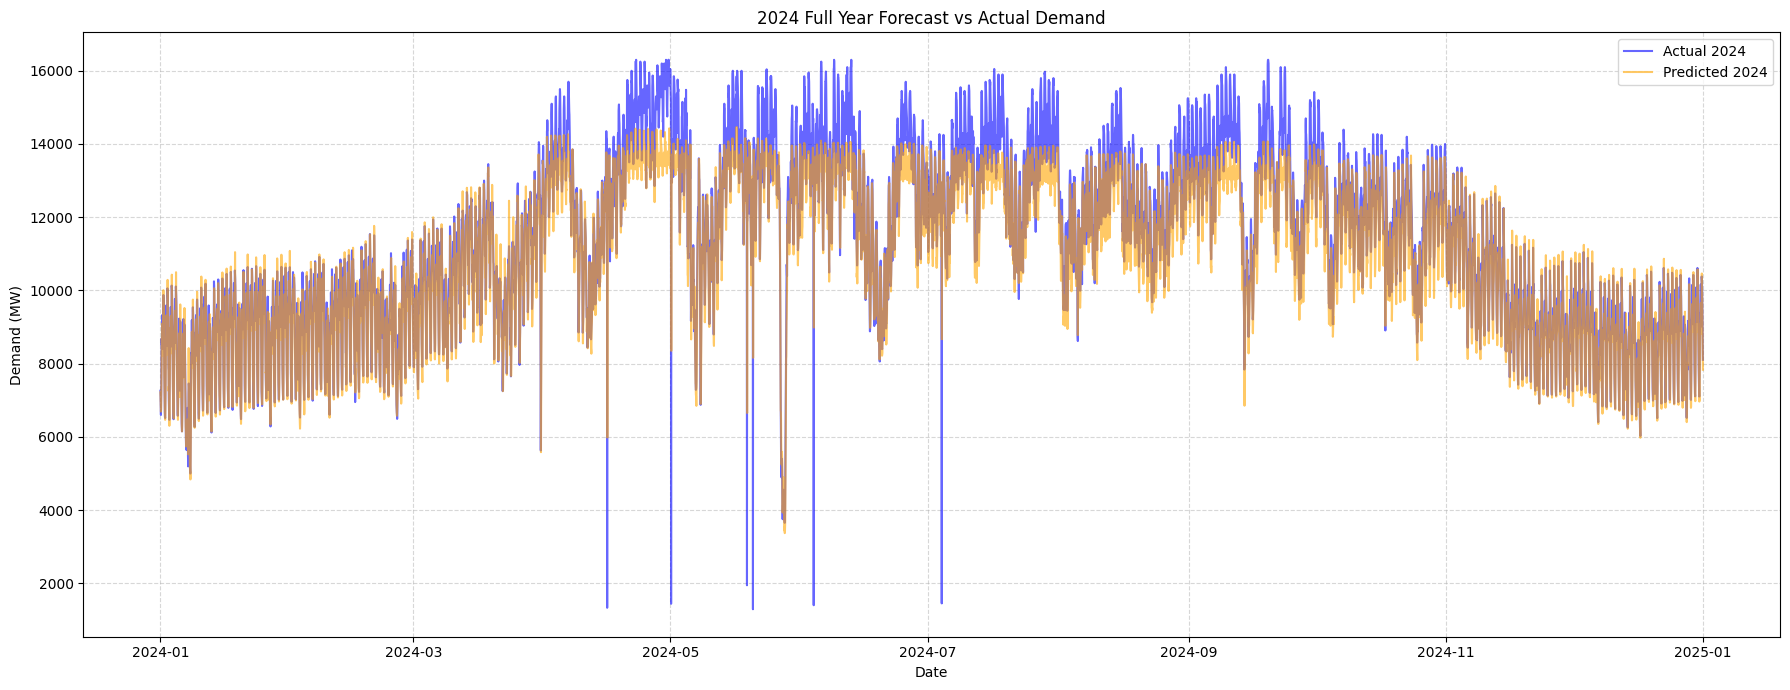

In [458]:
plt.figure(figsize=(18, 7))
plt.plot(df_2024['datetime'], y_2024, label='Actual 2024', alpha=0.6, color='blue')
plt.plot(df_2024['datetime'], preds_2024, label='Predicted 2024', alpha=0.6, color='orange')
plt.title('2024 Full Year Forecast vs Actual Demand')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#MAPE for the predicted demand for the year 2025

In [459]:
df_2025 = final_df[final_df['datetime'].dt.year == 2025].copy()

# Prepare features and target for 2025
X_2025 = df_2025.drop(columns=['datetime','target_next_hour_demand' , 'demand_mw', 'generation_mw', 'load_shedding', 'remarks', 'year'], errors='ignore')
y_2025 = df_2025['target_next_hour_demand']

# Generate predictions for 2025
preds_2025 = model.predict(X_2025)

# Calculate MAPE
mape_2025 = mean_absolute_percentage_error(y_2025, preds_2025)

print(f'Evaluation for Year 2025:')
print(f'Rows in 2025: {len(df_2025)}')
print(f'Mean Absolute Percentage Error (MAPE) for 2025: {mape_2025:.2%}')

Evaluation for Year 2025:
Rows in 2025: 4020
Mean Absolute Percentage Error (MAPE) for 2025: 4.00%


# Visualizing the actual versus predicted demand for the year 2025

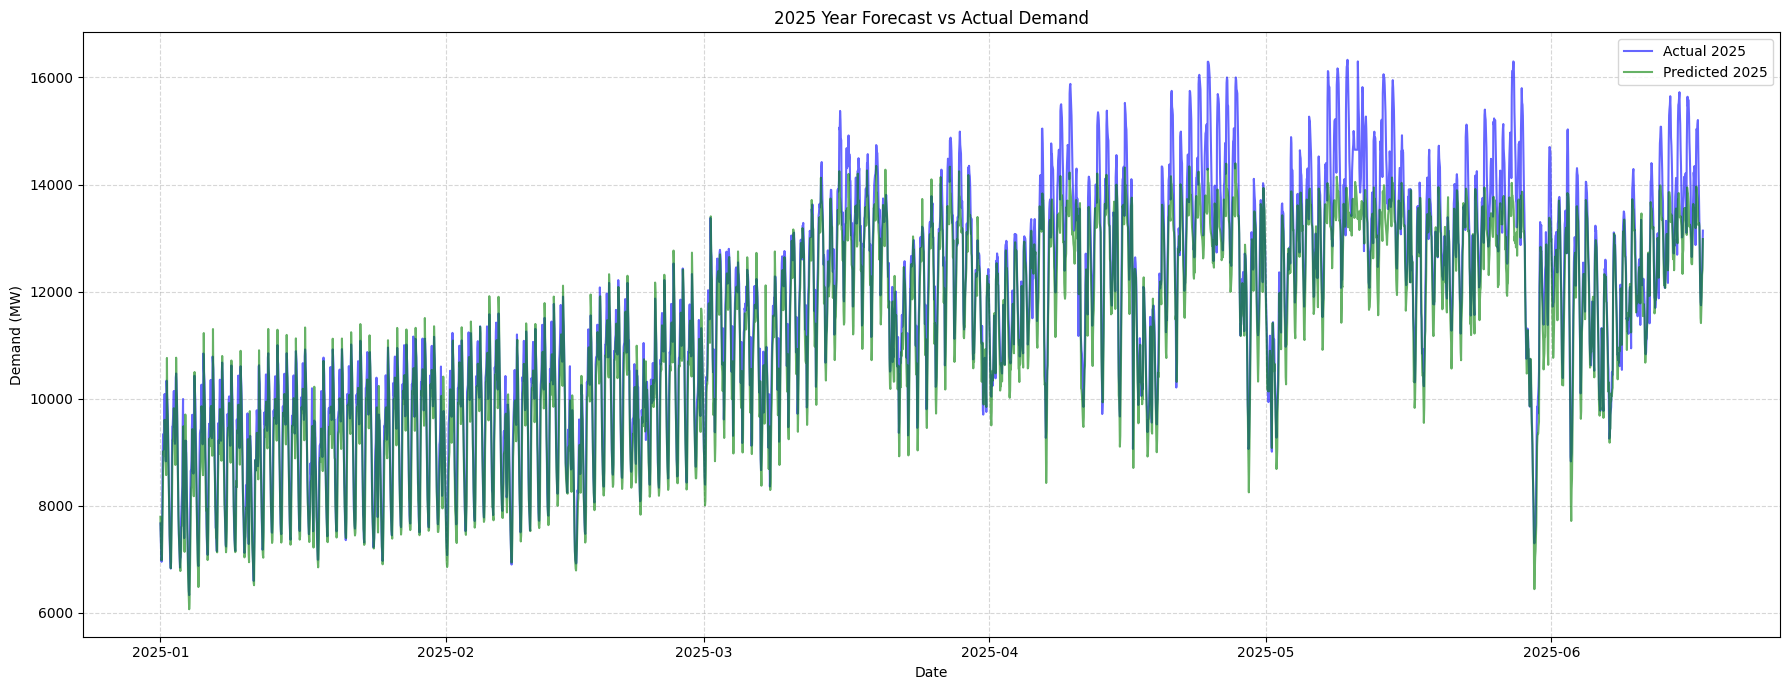

In [460]:
# Visualize 2025 Forecast vs Actuals
plt.figure(figsize=(18, 7))
plt.plot(df_2025['datetime'], y_2025, label='Actual 2025', alpha=0.6, color='blue')
plt.plot(df_2025['datetime'], preds_2025, label='Predicted 2025', alpha=0.6, color='green')
plt.title('2025 Year Forecast vs Actual Demand')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()